#Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings for better visuals
plt.rcParams['figure.figsize'] = (12,5)
sns.set_style("whitegrid")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

#Load Dataset

In [3]:
df = pd.read_csv("Crude oil.csv")
df.head()

,Date,Close/Last,Volume,Open,High,Low
0,10/28/2022,87.90,241417.0,88.67,88.76,87.08
1,10/27/2022,88.26,273717.0,88.26,89.79,87.33
2,10/26/2022,87.91,271474.0,85.07,88.41,84.14
3,10/25/2022,85.32,226337.0,84.88,86.03,83.06
4,10/24/2022,84.58,238458.0,85.24,85.92,82.63


#Data Preprocessing

In [4]:
# Convert Date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Rename column
df.rename(columns={'Close/Last': 'Close'}, inplace=True)

# Clean numeric columns
cols = ['Close', 'Open', 'High', 'Low', 'Volume']

for col in cols:
    df[col] = df[col].astype(str).str.replace(r'[\$,]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing values
df.dropna(inplace=True)

#Line Plot (Trend Over Time)

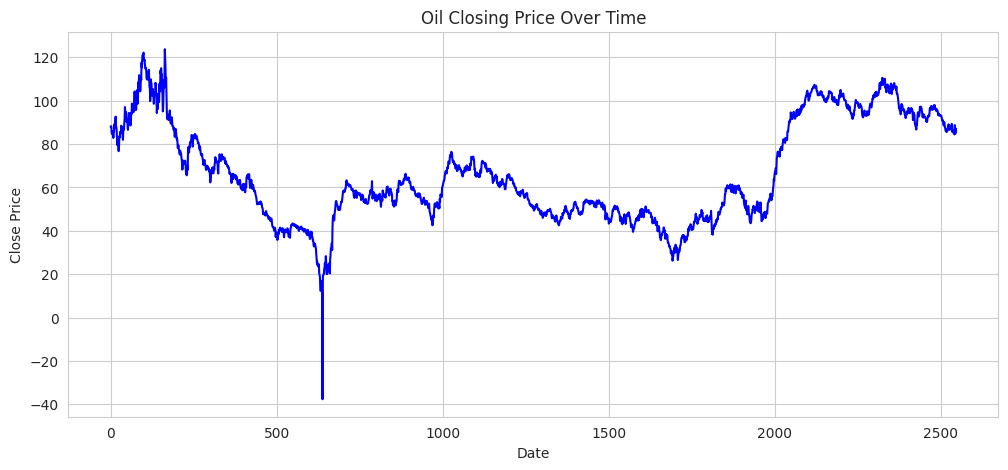

In [6]:
plt.plot(df.index, df['Close'], color='blue')
plt.title("Oil Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

#Histogram (Distribution)

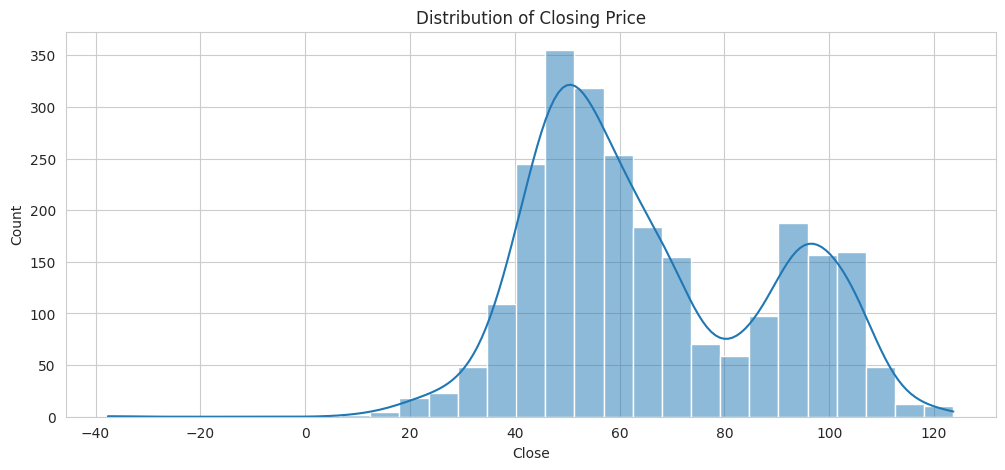

In [7]:
sns.histplot(df['Close'], kde=True)
plt.title("Distribution of Closing Price")
plt.show()

#Box Plot (Outliers)

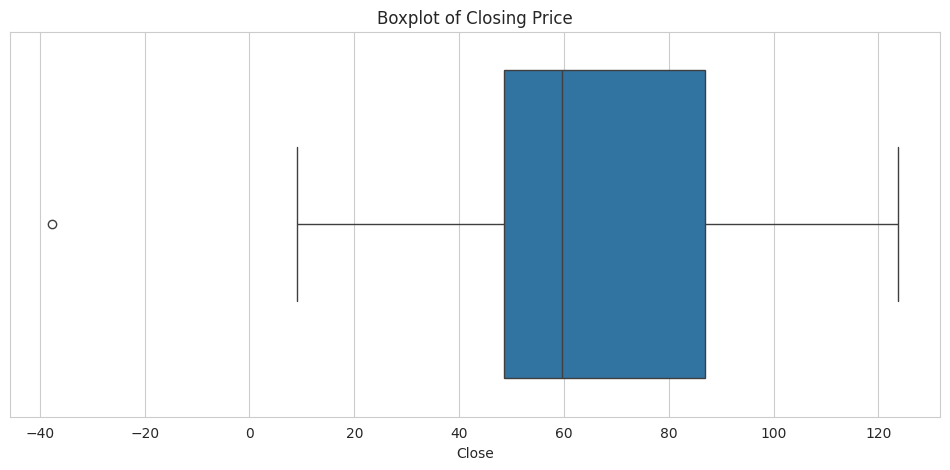

In [8]:
sns.boxplot(x=df['Close'])
plt.title("Boxplot of Closing Price")
plt.show()

#Monthly Average Trend

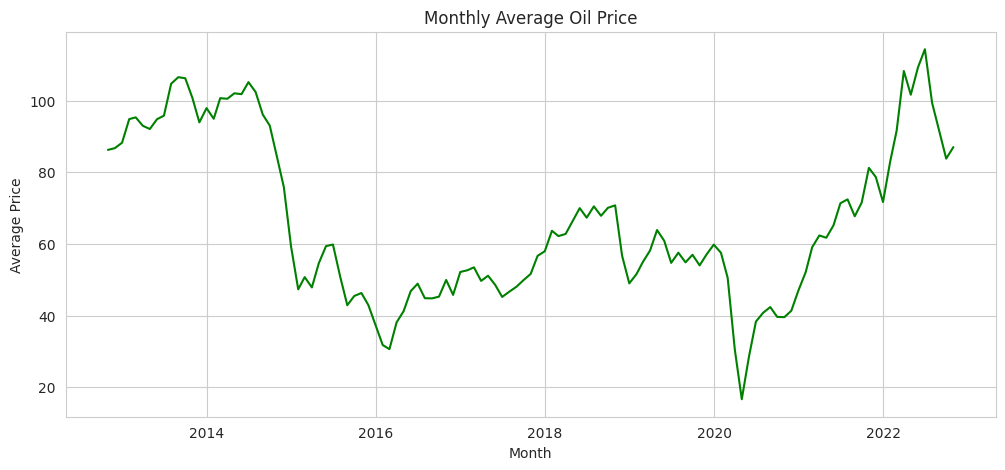

In [9]:
# Set 'Date' column as index for resampling
df_resampled = df.set_index('Date')
monthly_avg = df_resampled['Close'].resample('ME').mean()

plt.plot(monthly_avg, color='green')
plt.title("Monthly Average Oil Price")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.show()

#Rolling Mean (Smoothing)

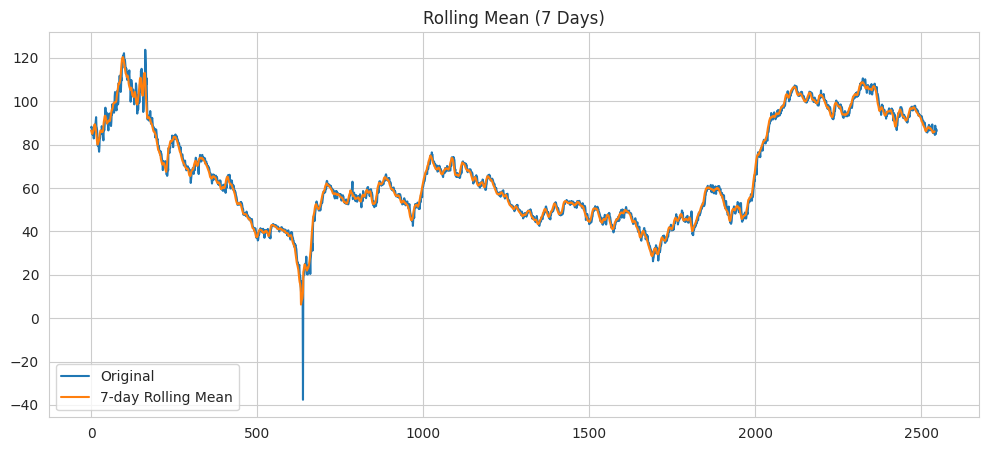

In [10]:
rolling_7 = df['Close'].rolling(window=7).mean()

plt.plot(df['Close'], label='Original')
plt.plot(rolling_7, label='7-day Rolling Mean')
plt.legend()
plt.title("Rolling Mean (7 Days)")
plt.show()

#Correlation Heatmap

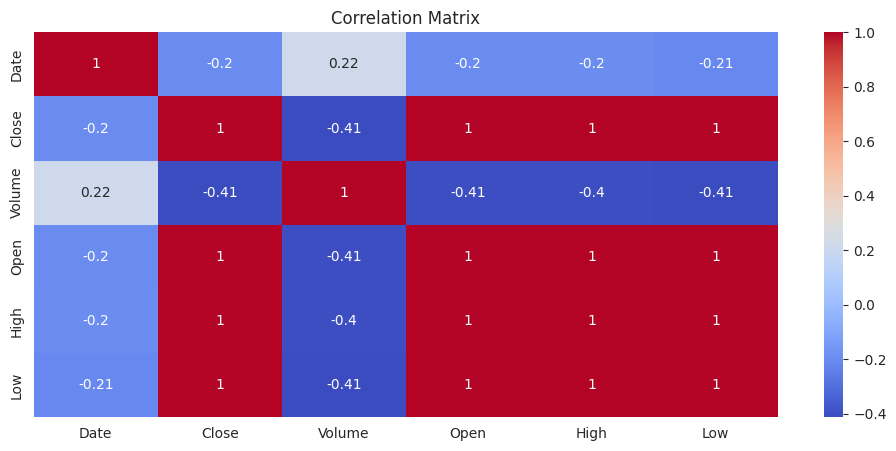

In [11]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#Seasonal Decomposition

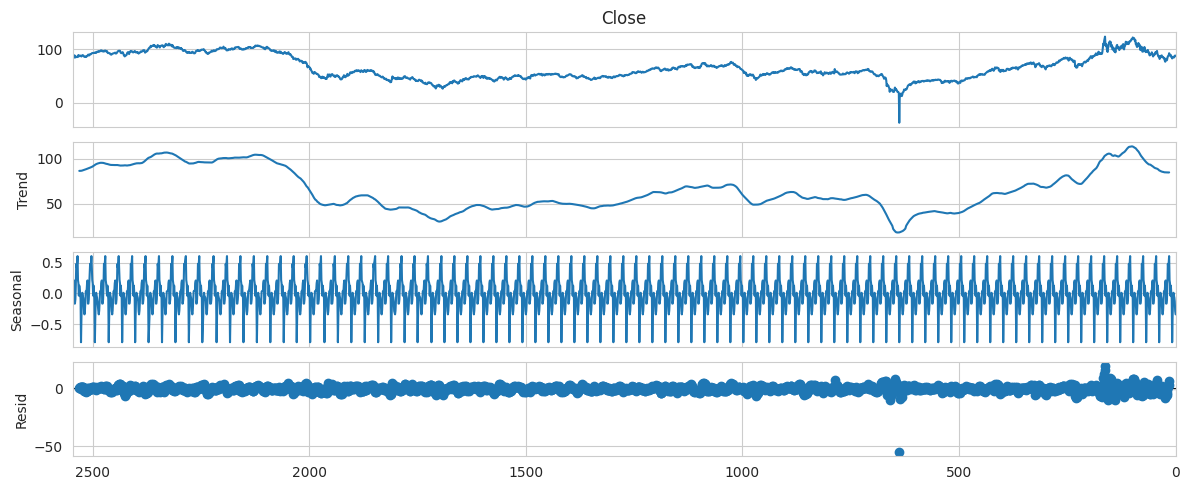

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Close'], model='additive', period=30)

df['trend'] = decomposition.trend
df['seasonal'] = decomposition.seasonal
df['residual'] = decomposition.resid
decomposition.plot()
plt.show()

#FEATURE ENGINEERING

In [13]:
# Time features
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.dayofweek

# Lag features
df['lag_1'] = df['Close'].shift(1)
df['lag_2'] = df['Close'].shift(2)
df['lag_3'] = df['Close'].shift(3)

# Rolling features
df['rolling_mean_3'] = df['Close'].rolling(3).mean()
df['rolling_std_3'] = df['Close'].rolling(3).std()

# Drop missing values
df.dropna(inplace=True)

#Define Features & Target

In [14]:
X = df.drop(['Close', 'Date'], axis=1)
y = df['Close']

#Prepare Data

In [17]:
data = df[['Close']]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

#Train-Test Split

In [18]:
train_size = int(len(scaled_data) * 0.8)

train = scaled_data[:train_size]
test = scaled_data[train_size:]

#Create Time Series Dataset

In [19]:
def create_dataset(data, time_step=10):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

time_step = 10

X_train, y_train = create_dataset(train, time_step)
X_test, y_test = create_dataset(test, time_step)

#MODEL — Linear Regression

In [20]:
X_train_lr = X_train.reshape(X_train.shape[0], -1)
X_test_lr = X_test.reshape(X_test.shape[0], -1)

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train)

y_pred_lr = lr_model.predict(X_test_lr)

#MODEL — ARIMA

In [21]:
train_arima = df['Close'][:train_size]
test_arima = df['Close'][train_size:]

model_arima = ARIMA(train_arima, order=(5,1,0))
model_arima_fit = model_arima.fit()

y_pred_arima = model_arima_fit.forecast(steps=len(test_arima))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

#MODEL — LSTM

In [22]:
model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model_lstm.add(LSTM(50))
model_lstm.add(Dense(1))

model_lstm.compile(loss='mean_squared_error', optimizer='adam')

model_lstm.fit(X_train, y_train, epochs=10, batch_size=32)

y_pred_lstm = model_lstm.predict(X_test)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0326
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.6257e-04
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.0808e-04
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4401e-04
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.4421e-04
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.4430e-04
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.4798e-04
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.3943e-04
Epoch 9/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3813e-04
Epoch 10/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.3941e-04
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


#Inverse Scaling

In [23]:
y_test_actual = scaler.inverse_transform(y_test)

y_pred_lr_actual = scaler.inverse_transform(y_pred_lr.reshape(-1,1))
y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm)

#Evaluation Function

In [24]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

#Evaluate Models

In [25]:
mae_lr, rmse_lr, r2_lr = evaluate(y_test_actual, y_pred_lr_actual)
mae_lstm, rmse_lstm, r2_lstm = evaluate(y_test_actual, y_pred_lstm_actual)
mae_arima, rmse_arima, r2_arima = evaluate(test_arima.values, y_pred_arima.values)

#Model Comparison Table

In [26]:
model_results = pd.DataFrame({
    "Model": ["Linear Regression", "ARIMA", "LSTM"],
    "MAE": [mae_lr, mae_arima, mae_lstm],
    "RMSE": [rmse_lr, rmse_arima, rmse_lstm],
    "R2 Score": [r2_lr, r2_arima, r2_lstm]
})

model_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.738157,2.547104,0.983672
1,ARIMA,36.347728,41.585382,-3.134790
2,LSTM,3.080614,4.325672,0.952909


#Best Model Selection

In [27]:
best_model = model_results.loc[model_results["R2 Score"].idxmax()]
print(best_model)

Model       Linear Regression
MAE                  1.738157
RMSE                 2.547104
R2 Score             0.983672
Name: 0, dtype: object


#Predictions Table (Test Data)

In [28]:
results_df = pd.DataFrame({
    "Date": df['Date'].iloc[-len(y_test_actual):].values,
    "Actual Price": y_test_actual.flatten(),
    "LR Prediction": y_pred_lr_actual.flatten(),
    "LSTM Prediction": y_pred_lstm_actual.flatten()
})

results_df.head()

,Date,Actual Price,LR Prediction,LSTM Prediction
0,2020-10-30,35.79,36.847130,40.063812
1,2020-11-02,36.81,36.143910,39.582726
2,2020-11-03,37.66,36.568427,39.090908
3,2020-11-04,39.15,37.256870,38.599976
4,2020-11-05,38.79,38.253458,38.336994


#FUTURE FORECAST (LSTM)

In [29]:
future_steps = 30

last_data = scaled_data[-time_step:]
temp_input = list(last_data.flatten())

lstm_forecast = []

for i in range(future_steps):
    x_input = np.array(temp_input[-time_step:])
    x_input = x_input.reshape(1, time_step, 1)

    yhat = model_lstm.predict(x_input, verbose=0)

    temp_input.append(yhat[0][0])
    lstm_forecast.append(yhat[0][0])

#Convert Forecast to Actual Prices

In [30]:
lstm_forecast_actual = scaler.inverse_transform(
    np.array(lstm_forecast).reshape(-1,1)
)

#Create Future Dates

In [31]:
last_date = df['Date'].iloc[-1]

future_dates = pd.date_range(start=last_date, periods=31, freq='D')[1:]

#Forecast Table

In [32]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Price": lstm_forecast_actual.flatten()
})

forecast_df.head()

,Date,Forecasted Price
0,2022-10-08,82.879730
1,2022-10-09,84.079247
2,2022-10-10,84.926270
3,2022-10-11,85.344513
4,2022-10-12,85.751091


#Final Visualization

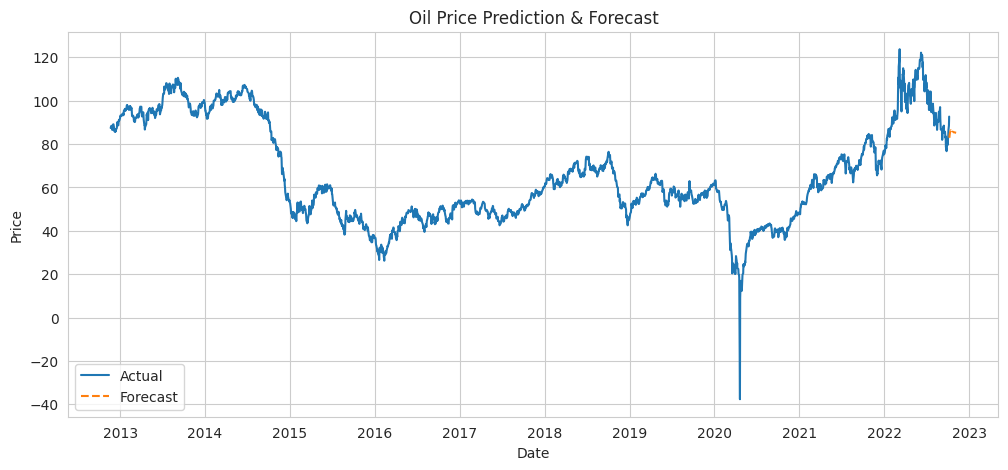

In [33]:
plt.figure()

plt.plot(df['Date'], df['Close'], label="Actual")
plt.plot(future_dates, lstm_forecast_actual, linestyle='dashed', label="Forecast")

plt.title("Oil Price Prediction & Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

#Model Comparison Bar Graph

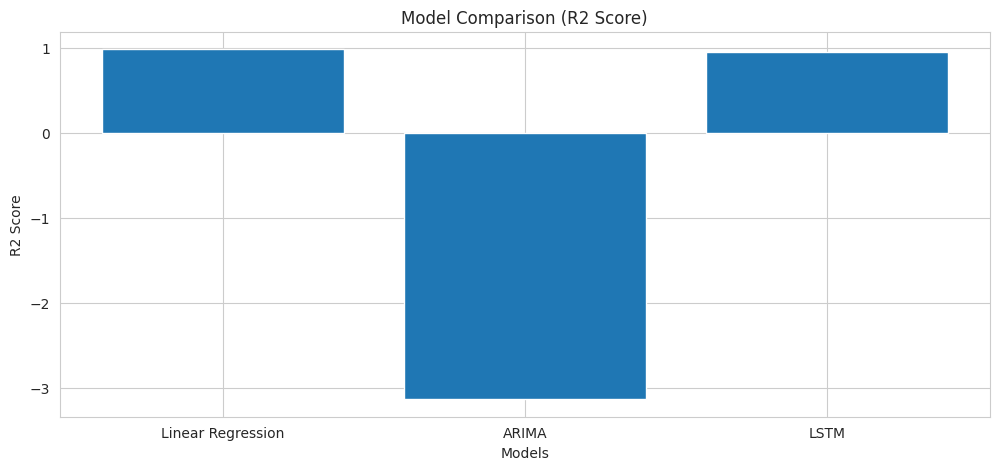

In [35]:
plt.figure()
plt.bar(model_results["Model"], model_results["R2 Score"])
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()